In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from scipy import stats

In [2]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

In [3]:
from preprocessing import *
from logistic_master import LogisticRegression
from utils import *

In [4]:
# bc
X_bc_train = np.load('../Data/processed/X_bc_train.npy')
X_bc_test  = np.load('../Data/processed/X_bc_test.npy')
y_bc_train = np.load('../Data/processed/y_bc_train.npy')
y_bc_test  = np.load('../Data/processed/y_bc_test.npy')

# db
X_db_train = np.load('../Data/processed/X_db_train.npy')
X_db_test  = np.load('../Data/processed/X_db_test.npy')
y_db_train = np.load('../Data/processed/y_db_train.npy')
y_db_test  = np.load('../Data/processed/y_db_test.npy')

# hd
X_hd_train = np.load('../Data/processed/X_hd_train.npy')
X_hd_test  = np.load('../Data/processed/X_hd_test.npy')
y_hd_train = np.load('../Data/processed/y_hd_train.npy')
y_hd_test  = np.load('../Data/processed/y_hd_test.npy')

# sty
X_st_train = np.load('../Data/processed/X_st_train.npy')
X_st_test  = np.load('../Data/processed/X_st_test.npy')
y_st_train = np.load('../Data/processed/y_st_train.npy')
y_st_test  = np.load('../Data/processed/y_st_test.npy')

print("Breast Cancer:" , X_bc_train.shape)
print("Diabetes:     " , X_db_train.shape)
print("Heart Disease:" , X_hd_train.shape)
print("Stroke:       " , X_st_train.shape)

Breast Cancer: (455, 21)
Diabetes:      (614, 9)
Heart Disease: (820, 14)
Stroke:        (4088, 22)


In [8]:
def compute_inference(model, X, y, feature_names):
    
    m = X.shape[0]
    
    # Step 1 - Hessian and Covariance Matrix
    H = model.compute_hessian(X, model.theta)
    C = np.linalg.pinv(H) / m
    
    # Step 2 - Standard Errors
    SE = np.sqrt(np.diag(C))
    
    # Step 3 - Z-scores
    theta_flat = model.theta.flatten()
    Z = theta_flat / SE
    
    # Step 4 - P-values (two-tailed)
    P = 2 * (1 - stats.norm.cdf(np.abs(Z)))
    
    # Step 5 - Confidence Intervals (95%)
    CI_lower = theta_flat - 1.96 * SE
    CI_upper = theta_flat + 1.96 * SE
    
    # Step 6 - Odds Ratios
    OR = np.exp(theta_flat)
    
    # Build DataFrame
    results = pd.DataFrame({
        'Feature'   : feature_names,
        'Coefficient': np.round(theta_flat, 4),
        'Std Error' : np.round(SE, 4),
        'Z-score'   : np.round(Z, 4),
        'P-value'   : np.round(P, 4),
        'CI Lower'  : np.round(CI_lower, 4),
        'CI Upper'  : np.round(CI_upper, 4),
        'Odds Ratio': np.round(OR, 4),
        'Significant': P < 0.05
    })
    
    return results

In [9]:
from tabulate import tabulate

datasets = {
    'Breast Cancer': (X_bc_train, X_bc_test, y_bc_train, y_bc_test, 21,  'newton'),
    'Diabetes':      (X_db_train, X_db_test, y_db_train, y_db_test, 9,   'newton'),
    'Heart Disease': (X_hd_train, X_hd_test, y_hd_train, y_hd_test, 14,  'newton'),
    'Stroke':        (X_st_train, X_st_test, y_st_train, y_st_test, 22,  'gd')
}

inference_results = {}

for name, (X_tr, X_te, y_tr, y_te, n_features, optimizer) in datasets.items():
    
    model = LogisticRegression()
    
    if optimizer == 'newton':
        model.fit_newton(X_tr, y_tr, max_iter=100, tol=1e-6)
    else:
        model.fit_gd(X_tr, y_tr, alpha=0.1, epochs=1000)
    
    # Generate feature names
    feature_names = ['bias'] + [f'feature_{i}' for i in range(1, n_features)]
    
    # Run inference
    results = compute_inference(model, X_tr, y_tr, feature_names)
    inference_results[name] = results
    
    sig_count = results['Significant'].sum()
    print(f"\n{name} — {sig_count}/{n_features} significant features")
    print(f"{'='*60}")
    print(tabulate(results, headers='keys', tablefmt='grid', showindex=False))


Breast Cancer — 7/21 significant features
+------------+---------------+-------------+-----------+-----------+------------+------------+--------------+---------------+
| Feature    |   Coefficient |   Std Error |   Z-score |   P-value |   CI Lower |   CI Upper |   Odds Ratio | Significant   |
+============+===============+=============+===========+===========+============+============+==============+===============+
| bias       |        0.5386 |      0.7083 |    0.7604 |    0.447  |    -0.8496 |     1.9268 |       1.7136 | False         |
+------------+---------------+-------------+-----------+-----------+------------+------------+--------------+---------------+
| feature_1  |       -5.757  |      2.249  |   -2.5598 |    0.0105 |   -10.1651 |    -1.349  |       0.0032 | True          |
+------------+---------------+-------------+-----------+-----------+------------+------------+--------------+---------------+
| feature_2  |       -2.7129 |      0.8704 |   -3.1166 |    0.0018 |    -4.

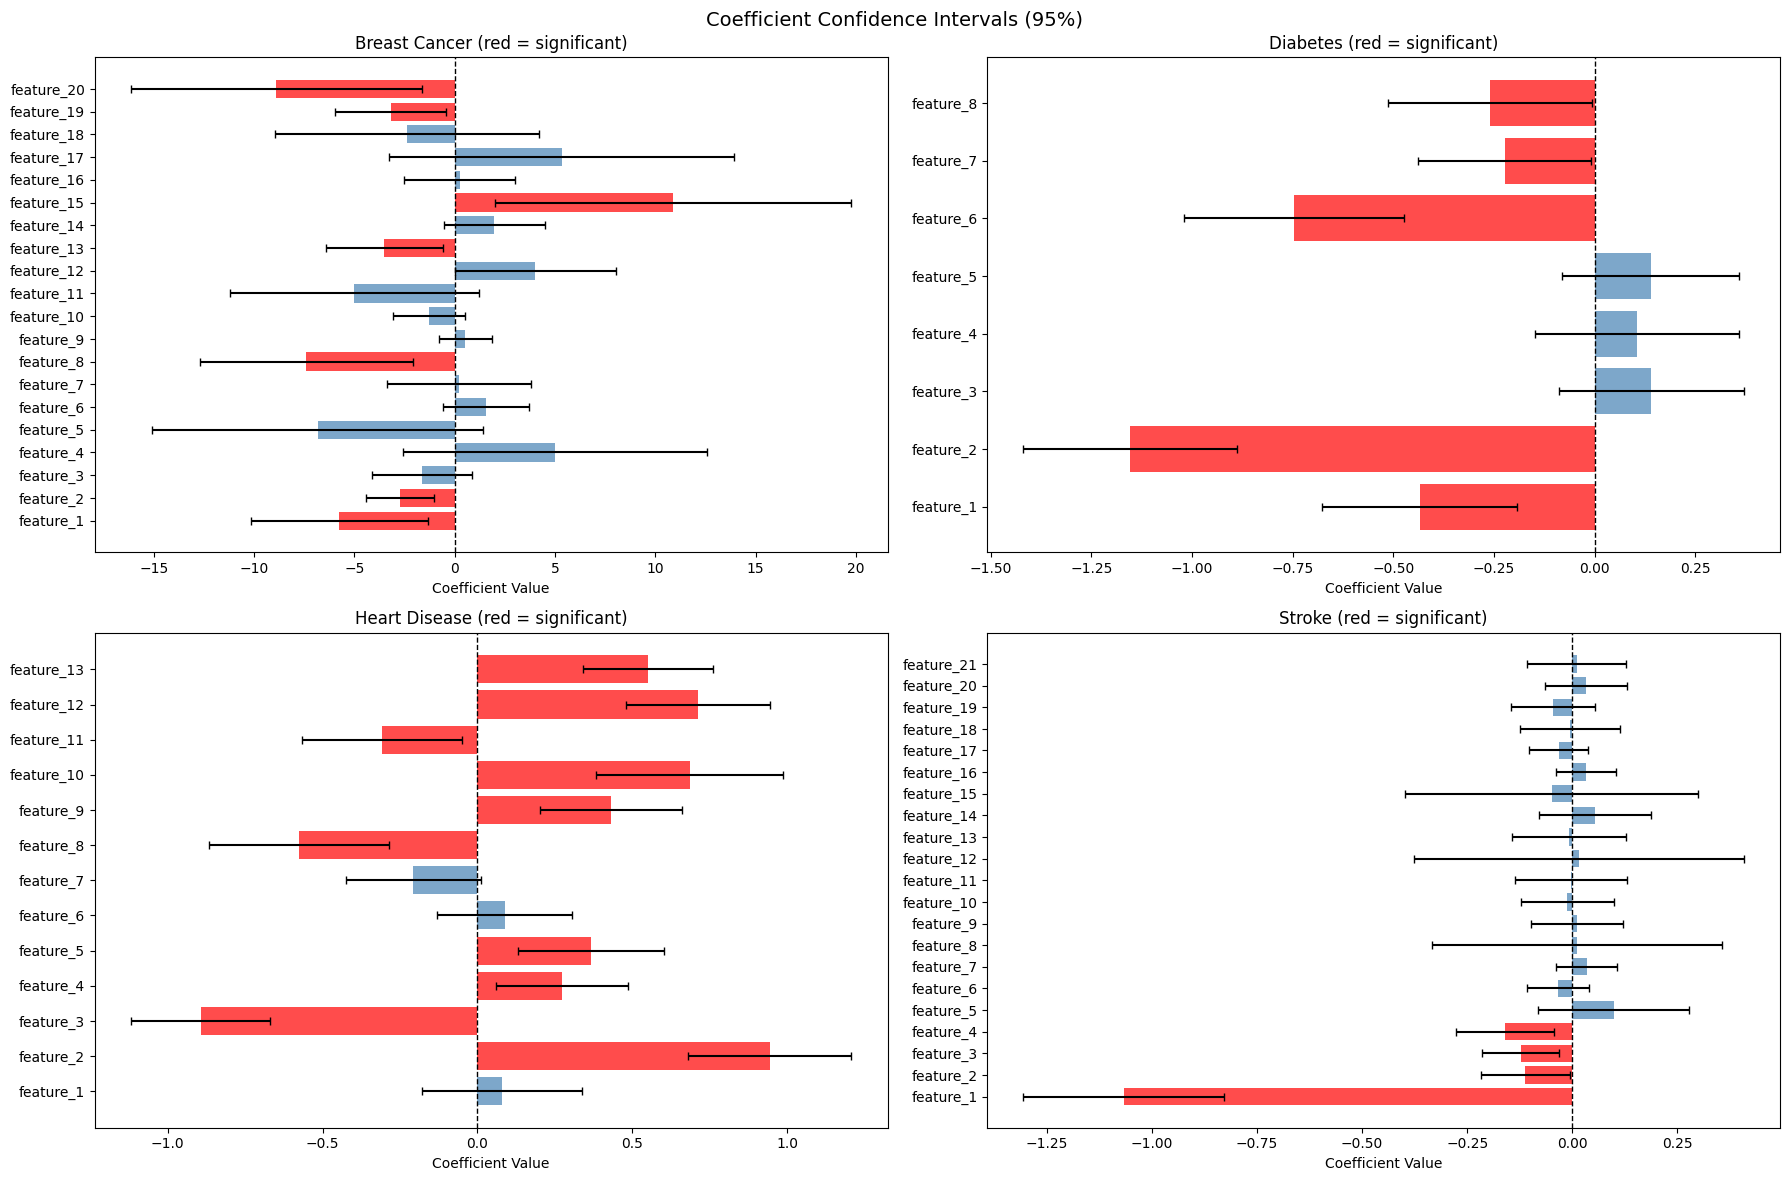

Saved.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Coefficient Confidence Intervals (95%)', fontsize=14)

for ax, (name, results) in zip(axes.flatten(), inference_results.items()):
    
    # Skip bias
    df = results[results['Feature'] != 'bias'].copy()
    
    colors = ['red' if s else 'steelblue' for s in df['Significant']]
    
    ax.barh(df['Feature'], df['Coefficient'], 
            xerr=1.96 * df['Std Error'],
            color=colors, alpha=0.7, capsize=3)
    
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f"{name} (red = significant)")
    ax.set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('../Results/figures/confidence_intervals.png', dpi=150)
plt.show()
print("Saved.")

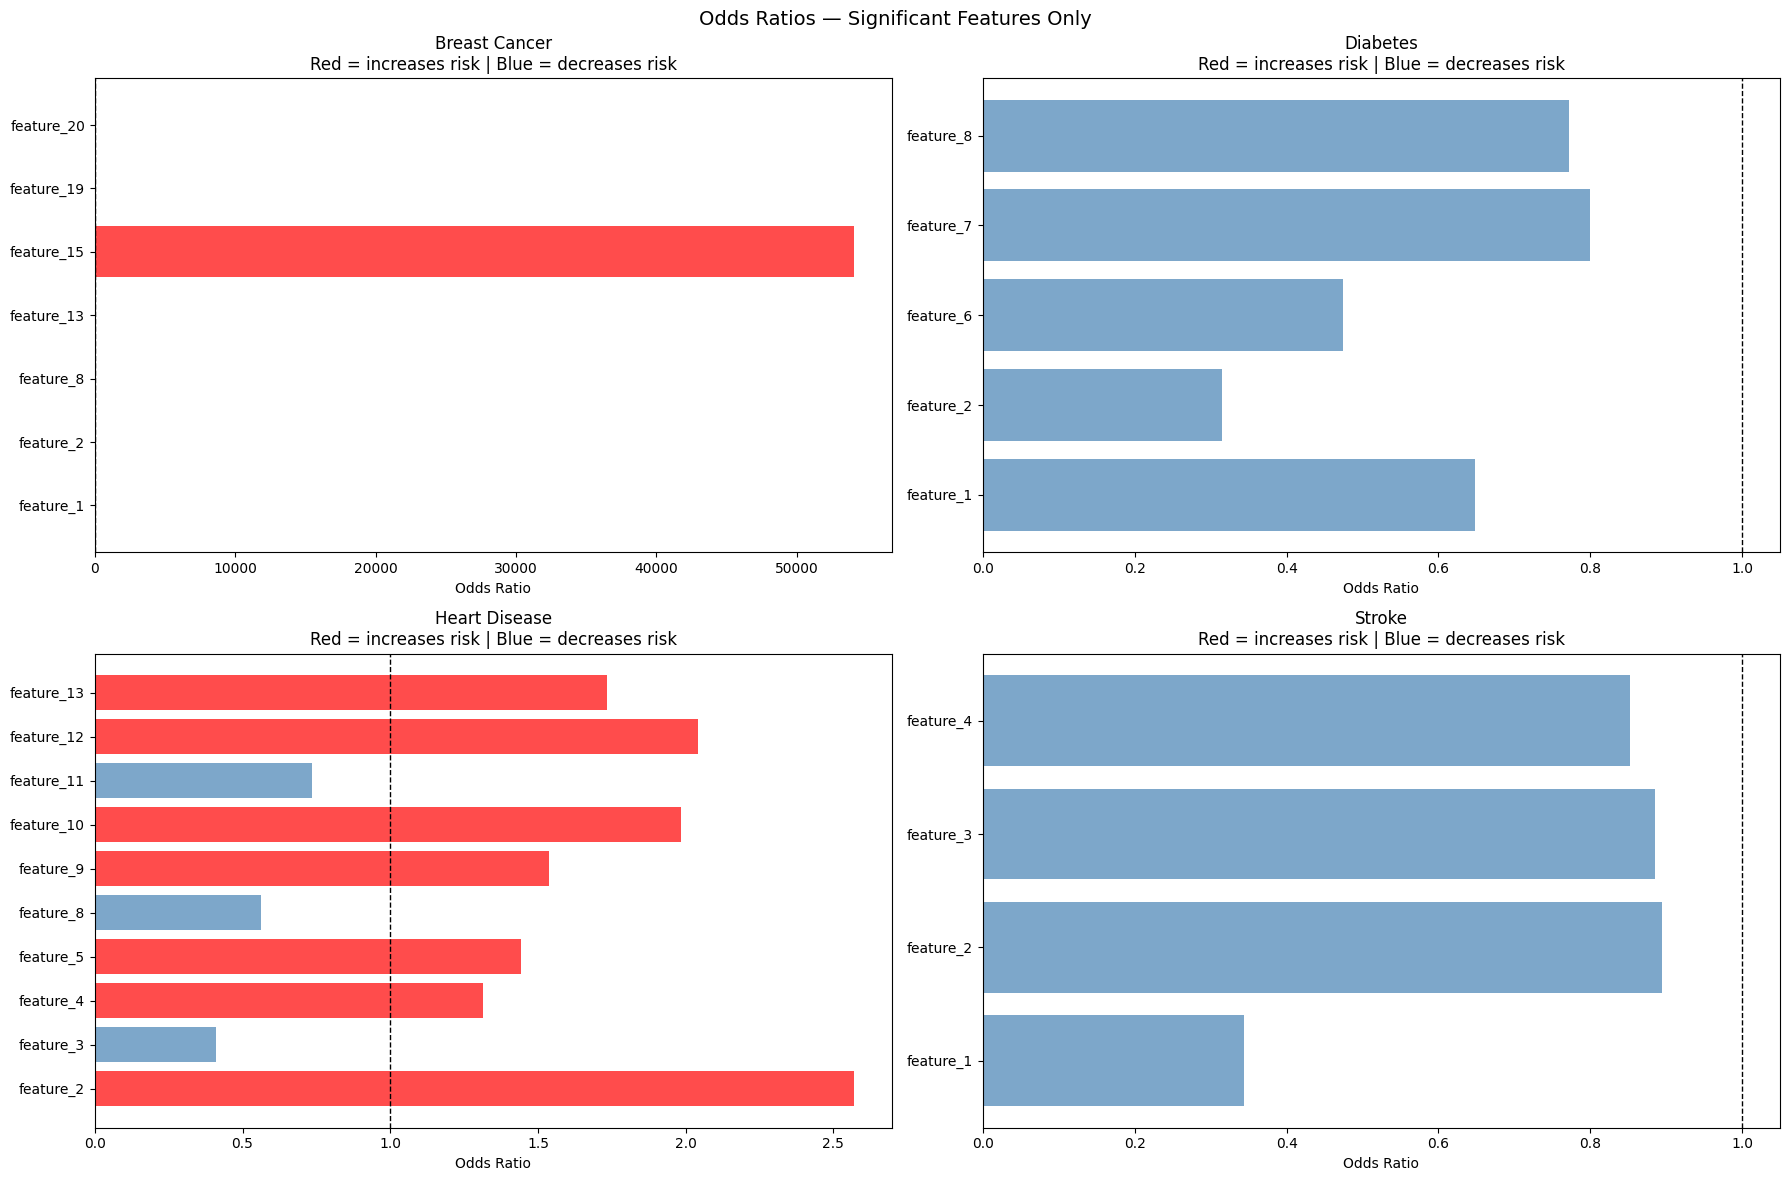

Saved.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Odds Ratios — Significant Features Only', fontsize=14)

for ax, (name, results) in zip(axes.flatten(), inference_results.items()):
    
    # Keep only significant features, skip bias
    df = results[(results['Significant'] == True) & 
                 (results['Feature'] != 'bias')].copy()
    
    if len(df) == 0:
        ax.set_title(f"{name} — no significant features")
        continue
    
    colors = ['red' if o > 1 else 'steelblue' for o in df['Odds Ratio']]
    
    ax.barh(df['Feature'], df['Odds Ratio'], color=colors, alpha=0.7)
    ax.axvline(1, color='black', linewidth=1, linestyle='--')
    ax.set_title(f"{name}\nRed = increases risk | Blue = decreases risk")
    ax.set_xlabel('Odds Ratio')

plt.tight_layout()
plt.savefig('../Results/figures/odds_ratios.png', dpi=150)
plt.show()
print("Saved.")

In [12]:
print("STATISTICAL INFERENCE SUMMARY")
print("="*60)

for name, results in inference_results.items():
    total = len(results) - 1  # exclude bias
    sig = results[results['Feature'] != 'bias']['Significant'].sum()
    
    # Most significant feature
    df = results[results['Feature'] != 'bias']
    top = df.loc[df['P-value'].idxmin()]
    
    # Strongest odds ratio
    sig_df = df[df['Significant'] == True]
    if len(sig_df) > 0:
        strongest_or = sig_df.loc[sig_df['Odds Ratio'].sub(1).abs().idxmax()]
    
    print(f"\n{name}")
    print(f"  Significant features : {sig}/{total}")
    print(f"  Most significant     : {top['Feature']} (p={top['P-value']:.4f}, Z={top['Z-score']:.4f})")
    print(f"  Strongest OR         : {strongest_or['Feature']} (OR={strongest_or['Odds Ratio']:.4f})")
    print(f"  Avg Std Error        : {df['Std Error'].mean():.4f}")

STATISTICAL INFERENCE SUMMARY

Breast Cancer
  Significant features : 7/20
  Most significant     : feature_2 (p=0.0018, Z=-3.1166)
  Strongest OR         : feature_15 (OR=54076.8177)
  Avg Std Error        : 2.3229

Diabetes
  Significant features : 5/8
  Most significant     : feature_2 (p=0.0000, Z=-8.5329)
  Strongest OR         : feature_2 (OR=0.3154)
  Avg Std Error        : 0.1244

Heart Disease
  Significant features : 10/13
  Most significant     : feature_2 (p=0.0000, Z=6.9950)
  Strongest OR         : feature_2 (OR=2.5698)
  Avg Std Error        : 0.1238

Stroke
  Significant features : 4/21
  Most significant     : feature_1 (p=0.0000, Z=-8.7753)
  Strongest OR         : feature_1 (OR=0.3439)
  Avg Std Error        : 0.0768


# Phase VII — Statistical Inference

## Objective
Move beyond prediction into explanation. Compute standard errors,
z-scores, p-values, confidence intervals, and odds ratios for each
feature coefficient across 4 datasets.

---

## Notebooks Created
- `Notebooks/07_Statistical_Inference.ipynb`

## Plots Generated
- `Results/figures/confidence_intervals.png`
- `Results/figures/odds_ratios.png`

---

## Datasets Used

| Dataset | Samples | Features | Optimizer Used |
|---|---|---|---|
| Breast Cancer | 455 | 21 | Newton |
| Diabetes | 614 | 9 | Newton |
| Heart Disease | 820 | 14 | Newton |
| Stroke | 4088 | 22 | GD (Hessian singular with Newton) |

**Adult Income and Credit Fraud excluded:**
- Adult Income — condition number 4.14e+16, Hessian inversion unreliable
- Credit Fraud — 0.17% imbalance makes p-values statistically unsound

---

## Inference Pipeline
```
theta → Hessian (H) → Covariance Matrix (pinv(H)/m)
      → Standard Errors (sqrt(diag(C)))
      → Z-scores (theta / SE)
      → P-values (2 * (1 - Φ(|Z|)))
      → Confidence Intervals (theta ± 1.96 * SE)
      → Odds Ratios (exp(theta))
```

Used `np.linalg.pinv` instead of `np.linalg.inv` to handle
near-singular Hessians gracefully.

---

## Results Summary

| Dataset | Significant Features | Most Significant | Strongest OR | Avg Std Error |
|---|---|---|---|---|
| Breast Cancer | 7/20 | feature_2 (p=0.0018) | feature_15 (OR=54076) | 2.3229 |
| Diabetes | 5/8 | feature_2 (p=0.0000) | feature_2 (OR=0.3154) | 0.1244 |
| Heart Disease | 10/13 | feature_2 (p=0.0000) | feature_2 (OR=2.5698) | 0.1238 |
| Stroke | 4/21 | feature_1 (p=0.0000) | feature_1 (OR=0.3439) | 0.0768 |

---

## Dataset Analysis

### Breast Cancer
- 7/20 features significant
- Avg Std Error 2.32 — highest uncertainty, tight feature-to-sample ratio
- feature_15 OR=54,076 — single feature almost perfectly predicts malignancy
- High uncertainty expected — 455 samples across 20 features

### Diabetes
- 5/8 features significant — strong signal on tiny dataset
- Avg Std Error 0.12 — very tight, coefficients highly reliable
- feature_2 dominates — most significant AND strongest odds ratio
- Simple 8-feature model, well-specified

### Heart Disease
- 10/13 significant — best inference result in entire project
- Avg Std Error 0.12 — equally tight as Diabetes
- Most well-specified model — small, clean, all numerical features
- Newton converged cleanly, Hessian well-conditioned

### Stroke
- Only 4/21 significant — one-hot encoding dilutes signal
- Avg Std Error 0.08 — tightest of all datasets
- Most features are noise — categorical encoding creates weak dummy variables
- GD used instead of Newton due to singular Hessian

---

## Key Findings

1. **Model quality depends on feature-to-sample ratio.**
   Heart Disease (820 samples, 14 features) gives cleaner inference
   than Breast Cancer (455 samples, 21 features).

2. **One-hot encoding hurts statistical inference.**
   Stroke has only 4/21 significant features because dummy variables
   split categorical signal across multiple weak columns.

3. **Extreme odds ratios signal near-perfect separation.**
   Breast Cancer feature_15 OR=54,076 means this feature almost
   perfectly separates malignant from benign cases.

4. **Condition number determines inference reliability.**
   Datasets with low condition numbers (Diabetes=2.49, Heart Disease)
   produce tight standard errors and reliable p-values.

5. **Bias significance has meaning.**
   Diabetes bias p=0.000 means baseline diabetes risk exists
   independent of all features — non-trivial intercept.

6. **pinv vs inv matters.**
   np.linalg.pinv handles near-singular Hessians from one-hot
   encoded datasets. np.linalg.inv fails on Stroke.

---

## Signal Quality Ranking

| Dataset | Signal Quality | Reason |
|---|---|---|
| Heart Disease | Strongest | Small, clean, all numerical |
| Diabetes | Strong | Few meaningful features |
| Breast Cancer | Moderate | High feature-to-sample ratio |
| Stroke | Weak | One-hot encoding dilutes signal |

---

